In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os

# Create output folders if not available
os.makedirs("../outputs/metrics", exist_ok=True)
os.makedirs("../outputs/plots", exist_ok=True)

In [2]:
df = pd.read_csv("../data/processed/monthly_sales.csv")
df["date"] = pd.to_datetime(df["date"])

ts = df.set_index("date")["sales"]

ts.head()

date
2003-01-31    129753.60
2003-02-28    140836.19
2003-03-31    174504.90
2003-04-30    201609.55
2003-05-31    192673.11
Name: sales, dtype: float64

In [3]:
train_size = int(len(ts) * 0.8)

train = ts[:train_size]
test = ts[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 23
Test size: 6


In [4]:
arima_pred_df = pd.read_csv("../outputs/metrics/arima_predictions.csv")
sarima_pred_df = pd.read_csv("../outputs/metrics/sarima_predictions.csv")
prophet_pred_df = pd.read_csv("../outputs/metrics/prophet_predictions.csv")

arima_pred_df["date"] = pd.to_datetime(arima_pred_df["date"])
sarima_pred_df["date"] = pd.to_datetime(sarima_pred_df["date"])
prophet_pred_df["date"] = pd.to_datetime(prophet_pred_df["date"])

arima_pred_df.head()

,date,actual,arima_pred
0,2004-12-31,372802.66,884539.434995
1,2005-01-31,339543.42,784400.880663
2,2005-02-28,358186.18,735367.581872
3,2005-03-31,374262.76,711358.204001
4,2005-04-30,261633.29,699601.902876


In [5]:
# ==============================
# Extract predictions
# ==============================

actual = test.values

arima_pred = arima_pred_df["arima_pred"].values
sarima_pred = sarima_pred_df["sarima_pred"].values
prophet_pred = prophet_pred_df.set_index("date").loc[test.index]["prophet_pred"].values

In [6]:
print("Actual:", len(actual))
print("ARIMA:", len(arima_pred))
print("SARIMA:", len(sarima_pred))
print("Prophet:", len(prophet_pred))

Actual: 6
ARIMA: 6
SARIMA: 6
Prophet: 6


In [7]:
def evaluate_model(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / (actual + 1e-10))) * 100
    
    return mae, rmse, mape

In [8]:
# ==============================
# Evaluate models
# ==============================

results = []

results.append(["ARIMA", *evaluate_model(actual, arima_pred)])
results.append(["SARIMA", *evaluate_model(actual, sarima_pred)])
results.append(["Prophet", *evaluate_model(actual, prophet_pred)])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "MAPE"])

results_df



,Model,MAE,RMSE,MAPE
0,ARIMA,390804.001823,400661.315616,113.765781
1,SARIMA,64401.158992,84183.064712,20.233686
2,Prophet,246870.244843,254172.765492,73.134161


In [9]:
# ==============================
# Save final model comparison results
# ==============================

results_df.to_csv("../outputs/metrics/model_results.csv", index=False)

print("Model comparison results saved successfully!")

Model comparison results saved successfully!


In [10]:
# ==============================
# Find best model based on MAPE
# ==============================

best_model = results_df.sort_values("MAPE").iloc[0]

print("Best Model:", best_model["Model"])
print("Best MAPE:", best_model["MAPE"])

Best Model: SARIMA
Best MAPE: 20.23368593941519


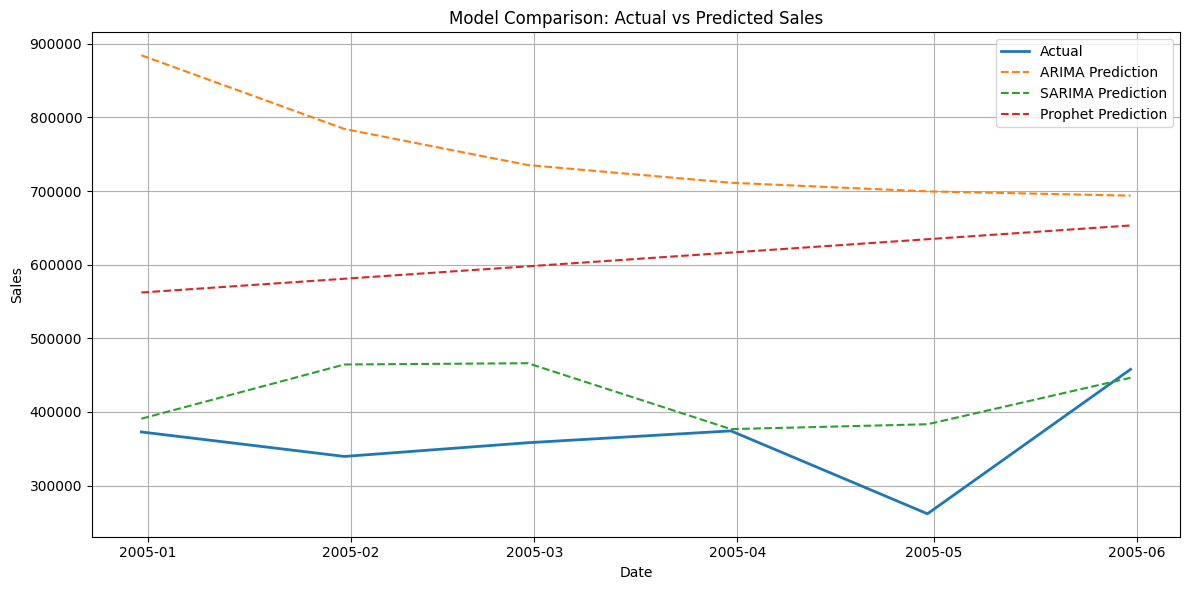

In [11]:
# ==============================
# Plot Actual vs Predicted
# ==============================

plt.figure(figsize=(12, 6))

plt.plot(test.index, actual, label="Actual", linewidth=2)
plt.plot(test.index, arima_pred, label="ARIMA Prediction", linestyle="--")
plt.plot(test.index, sarima_pred, label="SARIMA Prediction", linestyle="--")
plt.plot(test.index, prophet_pred, label="Prophet Prediction", linestyle="--")

plt.title("Model Comparison: Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("../outputs/plots/comparison.png", bbox_inches="tight")
plt.show()

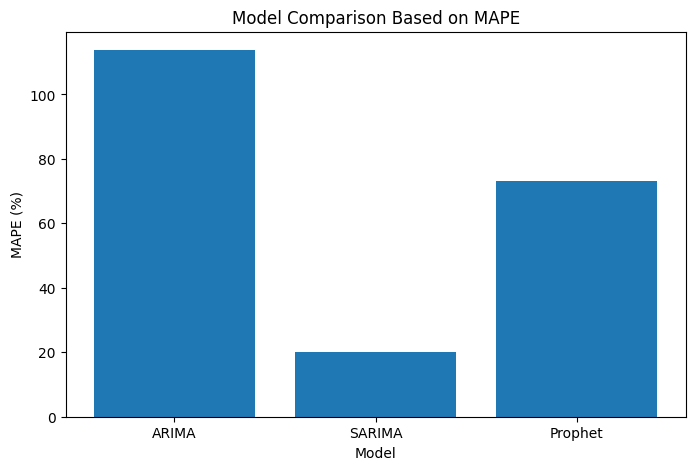

In [12]:
# ==============================
# Plot model metrics comparison
# ==============================

plt.figure(figsize=(8, 5))

plt.bar(results_df["Model"], results_df["MAPE"])

plt.title("Model Comparison Based on MAPE")
plt.xlabel("Model")
plt.ylabel("MAPE (%)")

plt.savefig("../outputs/plots/mape_comparison.png", bbox_inches="tight")
plt.show()

In [13]:
# ==============================
# Business insight generation
# ==============================

best_model_name = best_model["Model"]

if best_model_name == "ARIMA":
    best_pred = arima_pred
elif best_model_name == "SARIMA":
    best_pred = sarima_pred
else:
    best_pred = prophet_pred

avg_actual_demand = actual.mean()
avg_predicted_demand = best_pred.mean()

print("Average Actual Demand:", avg_actual_demand)
print("Average Predicted Demand:", avg_predicted_demand)

Average Actual Demand: 360714.895
Average Predicted Demand: 421289.76159102394


In [14]:
# ==============================
# Business recommendation
# ==============================

if avg_predicted_demand > avg_actual_demand * 1.10:
    recommendation = "Demand is expected to increase significantly. Increase inventory and prepare additional stock."
elif avg_predicted_demand < avg_actual_demand * 0.90:
    recommendation = "Demand is expected to decrease. Reduce inventory to avoid overstocking."
else:
    recommendation = "Demand is expected to remain stable. Maintain normal inventory levels."

print("Business Recommendation:")
print(recommendation)

Business Recommendation:
Demand is expected to increase significantly. Increase inventory and prepare additional stock.


In [15]:
# ==============================
# Save business insight
# ==============================

business_df = pd.DataFrame({
    "Best_Model": [best_model_name],
    "Average_Actual_Demand": [avg_actual_demand],
    "Average_Predicted_Demand": [avg_predicted_demand],
    "Recommendation": [recommendation]
})

business_df.to_csv("../outputs/metrics/business_insight.csv", index=False)

business_df

,Best_Model,Average_Actual_Demand,Average_Predicted_Demand,Recommendation
0,SARIMA,360714.895,421289.761591,Demand is expected to increase significantly. ...
